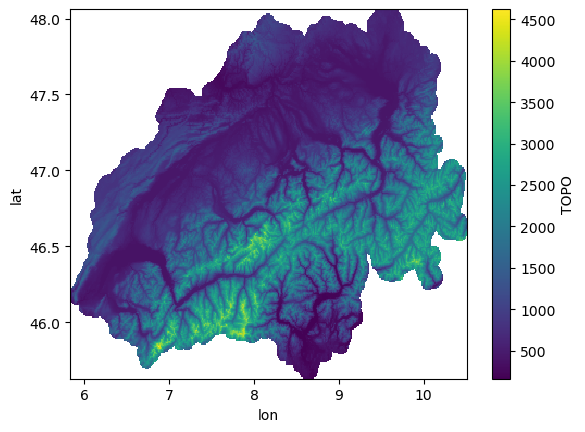

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
import matplotlib
import platform
import cartopy.crs as ccrs
import cartopy.io.shapereader as shapereader
import rioxarray
import glob
import pandas as pd
# set font type for PDFs and EPSs
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# make switch to windows if working from home
if platform.system() == 'Windows':
    base_dir = Path('L:\malle\CLM5_CH')
else:
    base_dir = Path('/home/lud11/malle/CLM5_CH')
    
dem_file = base_dir / 'BAFU_DEM_2020_1000.txt'
dem_array = rioxarray.open_rasterio(dem_file, parse_coordinates=True, masked=True)
dem_data_HR = dem_array.squeeze()

surf_05deg = xr.open_dataset(base_dir / 'surfdata_CH_05deg_v2_hist_16pfts_Irrig_CMIP6_simyr2000_c230113.nc')
lat_geo = surf_05deg.LATIXY[:, 0]
lon_geo = surf_05deg.LONGXY[0, :]
surf_05deg = surf_05deg.assign_coords({'lsmlon': lon_geo.data, 'lsmlat': lat_geo.data})

dem_data_LR = xr.open_dataset(base_dir / 'topodata_360x720_c060528.nc')
lat_geo = dem_data_LR.LATIXY[:, 0]
lon_geo = dem_data_LR.LONGXY[0, :]
dem_data_LR = dem_data_LR.assign_coords({'lsmlon': lon_geo.data, 'lsmlat': lat_geo.data})

input_highres = xr.open_dataset(base_dir / 'surfdata_1km_CH_v3_hist_16pfts_Irrig_CMIP6_NEW.nc')
lat_geo = input_highres.LATIXY[:, 0]
lon_geo = input_highres.LONGXY[0, :]
input_highres = input_highres.assign_coords({'lsmlon': lon_geo.data, 'lsmlat': lat_geo.data})

# make dataset for topo data
da = xr.DataArray(
    data=np.flipud(dem_data_HR.data),
    coords=[("lat", lat_geo.data),
            ("lon", lon_geo.data)]
    )
dem_data_HR = xr.Dataset(data_vars={"TOPO": da})
dem_data_HR.TOPO.plot()

countries = shapereader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_0_countries')

for country in shapereader.Reader(countries).records():
    if 'Switzerland' in country.attributes['NAME_EN']:
        switzerland = country.geometry
        break
else:
    raise ValueError('Unable to find the CH boundary.')

In [111]:
lat_in

array([271, 271, 271, 271, 271, 271, 271, 271, 271, 272, 272, 272, 272,
       272, 272, 272, 272, 272, 273, 273, 273, 273, 273, 273, 273, 273,
       273, 274, 274, 274, 274, 274, 274, 274, 274, 274, 275, 275, 275,
       275, 275, 275, 275, 275, 275])

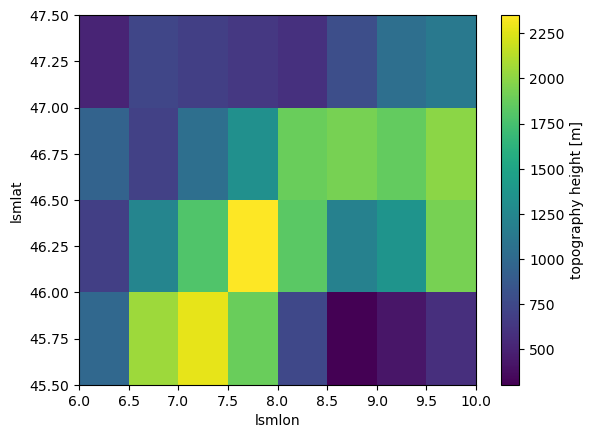

In [112]:
dem_data_LR.TOPO[lat_in[0]:lat_in[-1],lon_in[0]:lon_in[-1]].plot()

/home/malle/miniconda3/envs/new_python310/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:799: UserWarning: Approximating coordinate system <Geographic 2D CRS: +proj=lonlat +datum=WGS84 +ellps=WGS84 +no_defs +t ...>
Name: unknown
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
 with the PlateCarree projection.
  warnings.warn(f'Approximating coordinate system {crs!r} with '
/home/malle/miniconda3/envs/new_python310/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:799: UserWarning: Approximating coordinate system <Geographic 2D CRS: +proj=lonlat +datum=WGS84 +ellps=WGS84 +no_defs +t ...>
Name: unknown
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
 with the PlateCarree projection.
  warni

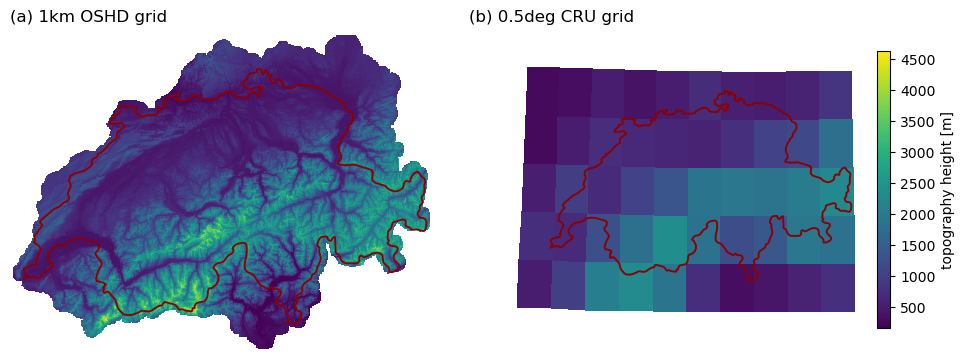

In [139]:
min_lat, max_lat = surf_05deg.LATIXY.min().data, surf_05deg.LATIXY.max().data
min_lon, max_lon = surf_05deg.LONGXY.min().data, surf_05deg.LONGXY.max().data
mask = ((dem_data_LR.LATIXY<=max_lat) & (dem_data_LR.LATIXY>=min_lat) & (dem_data_LR.LONGXY<=max_lon) & (dem_data_LR.LONGXY>=min_lon))
lat_in = np.where(mask ==True)[0]
lon_in = np.where(mask ==True)[1]

min_all = np.min([np.nanmin(dem_data_HR.TOPO.data), np.nanmin(dem_data_LR.TOPO[lat_in[0]:lat_in[-1]+1,lon_in[0]-1:lon_in[-1]+1].data)])
max_all = np.max([np.nanmax(dem_data_HR.TOPO.data), np.nanmax(dem_data_LR.TOPO[lat_in[0]:lat_in[-1]+1,lon_in[0]-1:lon_in[-1]+1].data)])

proj_data = ccrs.PlateCarree()
proj_map = ccrs.UTM(zone=32, southern_hemisphere=False)

fig1 = plt.figure(figsize=[12, 6])
ax1 = plt.subplot(121, projection=proj_map)
ax2 = plt.subplot(122, projection=proj_map)

dem_data_HR.TOPO.plot(ax=ax1, transform=proj_data, vmin=min_all, vmax=max_all, add_colorbar=False)
ax1.add_geometries([switzerland], ccrs.Geodetic(), edgecolor='darkred', linewidth=1.35, facecolor='none')
ax1.axis('off')
#dem_data_LR.TOPO.plot(ax=ax2, transform=proj_data)
dem_data_LR.TOPO[lat_in[0]:lat_in[-1]+1,lon_in[0]-1:lon_in[-1]+1].plot(ax=ax2, transform=proj_data, vmin=min_all, vmax=max_all, cbar_kwargs={'shrink':0.6})
ax2.add_geometries([switzerland], ccrs.Geodetic(), edgecolor='darkred', linewidth=1.35, facecolor='none')
ax2.axis('off')
ax1.set_title('(a) 1km OSHD grid', fontsize=12, loc='left')
ax2.set_title('(b) 0.5deg CRU grid', fontsize=12, x=0.1, y=1.15)

#plt.tight_layout()
fig1.savefig(base_dir / 'figures_revisions' / 'dem_comp.png', facecolor='white', transparent=False, bbox_inches='tight')
#dem_data_LR.sel('lsmlon'<min_lon)

In [120]:
dem_data_HR.TOPO.data

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [109]:
#dem_data_LR_cut = dem_data_LR[((dem_data_LR.LATIXY<=max_lat) & (dem_data_LR.LATIXY>=min_lat) & (dem_data_LR.LONGXY<=max_lon) & (dem_data_LR.LONGXY>=min_lon))]
dem_data_LR.LATIXY
dem_data_LR.LONGXY

mask

<xarray.DataArray (lsmlat: 360, lsmlon: 720)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * lsmlon   (lsmlon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lsmlat   (lsmlat) float64 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75

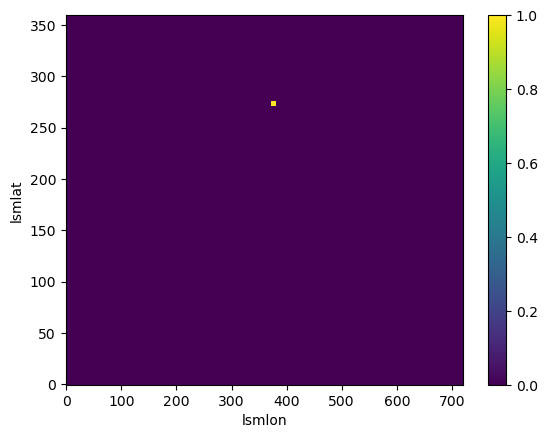

In [39]:
((dem_data_LR.LATIXY<=max_lat)& (dem_data_LR.LATIXY>=min_lat)&(dem_data_LR.LONGXY<=max_lon) & (dem_data_LR.LONGXY>=min_lon)).plot()